#CSE 25 Project - BTC Prediction Market

**Team**: Shrivas, Andrew, Siddarth

**Mentor:** Jiawei Fu





---




##**BTC Dataset**


### Step 1: Setup

In [1]:
# install yfinance
!pip install yfinance

# yfinance: pulls historical price data from Yahoo Finance
# pandas: useful for data cleaning and manipulation
# numpy : pandas use this for math

import yfinance as yf
import pandas as pd
import numpy as np
import requests

  Using cached pandas-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached websockets-16.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached cffi-2.0.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-macos

In [2]:
import requests
import pandas as pd

# ── Step 1: Find the market and its token IDs ──────────────────────────────
res = requests.get(
    "https://gamma-api.polymarket.com/events",
    params={"slug": "what-price-will-bitcoin-hit-in-may-2026"}
)
event = res.json()[0]  # grab the first result

# This market has multiple outcomes (↑90k, ↑100k, ↑105k, etc.)
# Print them all so you can pick the one most interesting to trade
print("Outcomes available:")
for market in event["markets"]:
    print(f"  {market['question']}  →  token: {market['clobTokenIds']}")

Outcomes available:
  Will Bitcoin reach $115,000 in May?  →  token: ["112483319947998004647217080905496446170602622172526076558318834324541958653454", "16748857912398914355191833003518205315915666088521477047521226979492030162264"]
  Will Bitcoin reach $105,000 in May?  →  token: ["26553531074963172435854421374327224528641451330453925097022737708076261558968", "44837352576386718440190165117570245172625565353142309731412742684480956410282"]
  Will Bitcoin reach $95,000 in May?  →  token: ["75068694519235284923554014292149365814905672168186840117079081703620417733601", "16860625162494210689460390678673570106526806365249676317752175720098998598727"]
  Will Bitcoin reach $85,000 in May?  →  token: ["27263818818572382308786837280052567231404272927433091805576135922512093801450", "20970486708225968446432942645112973151689471027935743232114605753310238562505"]
  Will Bitcoin dip to $75,000 in May?  →  token: ["85255397873237558858447685287854751130109864480350032224451058169602594241557", "5

In [ ]:
# Will Bitcoin reach $85,000 in May?
TOKEN_ID = "27263818818572382308786837280052567231404272927433091805576135922512093801450"

res = requests.get(
    "https://clob.polymarket.com/prices-history",
    params={
        "market": TOKEN_ID,
        "interval": "1w",
        "fidelity": 5
    }
)

history = res.json()["history"]
poly = pd.DataFrame(history)
poly.columns = ["timestamp", "poly_price"]
poly["datetime"] = pd.to_datetime(poly["timestamp"], unit="s", utc=True)
poly = poly.set_index("datetime").drop(columns="timestamp")

print(f"Got {len(poly)} rows")
print(f"From: {poly.index[0]}")
print(f"To:   {poly.index[-1]}")
print(f"Price range: {poly['poly_price'].min():.3f} → {poly['poly_price'].max():.3f}")
poly.head()

Got 2007 rows
From: 2026-05-11 21:50:04+00:00
To:   2026-05-18 21:40:06+00:00
Price range: 0.115 → 0.645


,poly_price
datetime,
2026-05-11 21:50:04+00:00,0.620
2026-05-11 21:55:12+00:00,0.625
2026-05-11 22:00:13+00:00,0.625
2026-05-11 22:05:05+00:00,0.635
2026-05-11 22:10:05+00:00,0.635


### 2. Download BTC Data and create features

>We will pull 1 min BTC candles from Yahoo Finance and add the features from our proposal: 1m / 5m / 15m returns, rolling volatility, and short vs. long moving averages.



In [ ]:
def load_btc_data(period = "7d", interval = "1m"):
  '''Download BTC and add features'''

  # download the raw price data from Yahoo finance
  # the period = "7d" -> last 7 days
  # interval = "1m" -> one row per min
  raw = yf.download( "BTC-USD", period = period, interval = interval,
                    progress = False, auto_adjust=True)

  # yfinance sometimes have multi level column index so we need to flatten it
  # the columns are just "Open", "Close",
  if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

  # will only keep the O.H.L.C.V. columns and will drop any rows missing data
  df = raw[["Open", "High", "Low", "Close", "Volume"]].copy().dropna()


  ''' Feature 1: short term returns '''

  # the .pct_change(n) is the % change from n rows ago
  # it will tell the model how much the price has moved over the timespan
  df["return_1m"] = df["Close"].pct_change(1)
  df["return_5m"] = df["Close"].pct_change(5)
  df["return_15m"] = df["Close"].pct_change(15)

  ''' Feature 2: rolling volatility '''

  # standard deviation of the last ten 1m returns
  # if high value, the price has been jumpy recently
  # if low value, calm market

  df["volatility"] = df["return_1m"].rolling(10).std()


  ''' Feature 3: simple moving averages & difference '''

  # sma_5 -> the avg price over the last 5 mins (short term trend)
  # sma_15 -> the avg price over the last 15 min (longer term trend)
  # if sma_diff > 0 -> bullish; < 0 -> bearish

  df["sma_5"] = df["Close"].rolling(5).mean()
  df["sma_15"] = df["Close"].rolling(15).mean()
  df["sma_diff"] = df["sma_5"] - df["sma_15"]


  return df.dropna()

  # check and run the loader
btc = load_btc_data()
print(f"Loaded {len(btc):,} rows from {btc.index[0]} to {btc.index[-1]}")
btc.tail()




Loaded 9,927 rows from 2026-05-12 00:15:00+00:00 to 2026-05-18 21:47:00+00:00


Price,Open,High,Low,Close,Volume,return_1m,return_5m,return_15m,volatility,sma_5,sma_15,sma_diff
Datetime,,,,,,,,,,,,
2026-05-18 21:43:00+00:00,76988.242188,76988.242188,76962.898438,76976.773438,64430080,-0.000149,0.000602,-0.000042,0.000590,76986.950000,77003.997917,-17.047917
2026-05-18 21:44:00+00:00,76981.593750,76981.593750,76949.000000,76975.296875,0,-0.000019,-0.000255,0.000041,0.000474,76983.015625,77004.208333,-21.192708
2026-05-18 21:45:00+00:00,76988.187500,77025.796875,76983.890625,76983.890625,0,0.000112,0.000217,-0.000151,0.000468,76986.353125,77003.434896,-17.081771
2026-05-18 21:46:00+00:00,76980.250000,76980.281250,76928.507812,76928.507812,0,-0.000719,-0.001027,-0.001329,0.000512,76970.539062,76996.611458,-26.072396
2026-05-18 21:47:00+00:00,76952.546875,76952.546875,76952.546875,76952.546875,0,0.000312,-0.000463,-0.001256,0.000527,76963.403125,76990.158333,-26.755208


In [ ]:
# ── Merge Polymarket price into BTC dataframe ─────────────────────────────

# Deduplicate poly index before resampling (API sometimes returns duplicate timestamps)
poly = poly[~poly.index.duplicated(keep='first')]

# Resample poly to 1-minute frequency by forward-filling
poly_1m = poly.resample("1min").ffill()

# Merge on datetime index — only keep rows where both exist
btc_poly = btc.join(poly_1m, how="inner")

print(f"Rows before merge: {len(btc):,}")
print(f"Rows after merge:  {len(btc_poly):,}")
print(f"Time range: {btc_poly.index[0]} → {btc_poly.index[-1]}")
print(f"\nPolymarket price stats:")
print(btc_poly["poly_price"].describe().round(3))
btc_poly[["Close", "poly_price"]].tail(10)

Rows before merge: 9,927
Rows after merge:  9,920
Time range: 2026-05-12 00:15:00+00:00 → 2026-05-18 21:40:00+00:00

Polymarket price stats:
count    9920.000
mean        0.340
std         0.149
min         0.115
25%         0.195
50%         0.355
75%         0.495
max         0.625
Name: poly_price, dtype: float64


,Close,poly_price
2026-05-18 21:31:00+00:00,77030.859375,0.125
2026-05-18 21:32:00+00:00,77049.343750,0.125
2026-05-18 21:33:00+00:00,77100.906250,0.125
2026-05-18 21:34:00+00:00,77011.242188,0.125
2026-05-18 21:35:00+00:00,77028.039062,0.125
2026-05-18 21:36:00+00:00,77011.226562,0.125
2026-05-18 21:37:00+00:00,76995.476562,0.125
2026-05-18 21:38:00+00:00,76930.492188,0.125
2026-05-18 21:39:00+00:00,76994.968750,0.125
2026-05-18 21:40:00+00:00,76967.203125,0.125


In [ ]:
def chronological_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    i1 = int(n * train_frac)
    i2 = int(n * (train_frac + val_frac))
    return df.iloc[:i1].copy(), df.iloc[i1:i2].copy(), df.iloc[i2:].copy()

def normalize(train, val, test, cols):
    means = train[cols].mean()
    stds  = train[cols].std().replace(0, 1.0)
    for split in (train, val, test):
        for c in cols:
            split[c + "_z"] = (split[c] - means[c]) / stds[c]
    return train, val, test

### 3. 70 / 15 / 15 Chronological split
> split by time, not randomly. This will avoid leaking future prices into training.

In [ ]:
# Change btc → btc_poly
train, val, test = chronological_split(btc_poly)

print(f"train: {len(train):>5} rows   {train.index[0]}  →  {train.index[-1]}")
print(f"val:   {len(val):>5} rows   {val.index[0]}  →  {val.index[-1]}")
print(f"test:  {len(test):>5} rows   {test.index[0]}  →  {test.index[-1]}")

# Add poly_price to normalization
Features_to_normalize = ["return_1m", "return_5m", "return_15m",
                         "volatility", "sma_diff", "poly_price"]

train, val, test = normalize(train, val, test, Features_to_normalize)
print("\nNormalized columns:")
z_cols = [c + "_z" for c in Features_to_normalize]
print(train[z_cols].agg(["mean", "std"]).round(3))

train:  6944 rows   2026-05-12 00:15:00+00:00  →  2026-05-16 20:02:00+00:00
val:    1488 rows   2026-05-16 20:03:00+00:00  →  2026-05-17 20:51:00+00:00
test:   1488 rows   2026-05-17 20:52:00+00:00  →  2026-05-18 21:40:00+00:00

Normalized columns:
      return_1m_z  return_5m_z  return_15m_z  volatility_z  sma_diff_z  \
mean          0.0          0.0          -0.0           0.0        -0.0   
std           1.0          1.0           1.0           1.0         1.0   

      poly_price_z  
mean          -0.0  
std            1.0  


# State Builder (Environment Setup)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random

# ── 1. Neural Network (replaces Q-table) ─────────────────────────────────
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )

    def forward(self, x):
        return self.net(x)

# ── 2. State builder (now continuous, no more buckets) ────────────────────
FEATURE_COLS = ["return_1m_z", "return_5m_z", "return_15m_z",
                "volatility_z", "sma_diff_z", "poly_price_z"]

def build_state_vector(row, position):
    # position encoded as: flat=0, long=1
    pos = 1.0 if position == "long" else 0.0
    features = [float(row[c]) for c in FEATURE_COLS]
    features.append(pos)
    return np.array(features, dtype=np.float32)  # shape: (7,)

STATE_SIZE  = len(FEATURE_COLS) + 1  # 6 features + position = 7
ACTION_SIZE = 3                       # 0=hold, 1=buy, 2=sell

print(f"State size: {STATE_SIZE}")
print(f"Action size: {ACTION_SIZE}")

# ── 3. Replay Buffer ──────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions),
                np.array(rewards), np.array(next_states),
                np.array(dones))

    def __len__(self):
        return len(self.buffer)

print("DQN components defined successfully")

State size: 7
Action size: 3
DQN components defined successfully


In [ ]:
# ── DQN Training Loop ─────────────────────────────────────────────────────

# Hyperparameters
EPISODES    = 500
BATCH_SIZE  = 64
GAMMA       = 0.99   # discount factor
LR          = 1e-3   # learning rate
EPS_START   = 1.0    # exploration start
EPS_END     = 0.01   # exploration end
EPS_DECAY   = 0.995  # multiply epsilon each episode
UPDATE_FREQ = 4      # train every N steps

# Initialize
policy_net = DQN(STATE_SIZE, ACTION_SIZE)
target_net = DQN(STATE_SIZE, ACTION_SIZE)
target_net.load_state_dict(policy_net.state_dict())  # copy weights
optimizer  = optim.Adam(policy_net.parameters(), lr=LR)
buffer     = ReplayBuffer(capacity=10_000)
epsilon    = EPS_START

episode_rewards = []

for episode in range(1, EPISODES + 1):
    position  = "flat"
    entry_price = 0.0
    total_reward = 0.0

    for i in range(len(train) - 1):
        row      = train.iloc[i]
        next_row = train.iloc[i + 1]

        state      = build_state_vector(row, position)
        next_state = build_state_vector(next_row, position)

        # ── Epsilon-greedy action selection ───────────────────────────
        if random.random() < epsilon:
            action = random.randint(0, ACTION_SIZE - 1)
        else:
            with torch.no_grad():
                q_vals = policy_net(torch.FloatTensor(state))
                action = q_vals.argmax().item()

        # ── Execute action & compute reward ───────────────────────────
        current_price = float(row["Close"])
        next_price    = float(next_row["Close"])
        poly_now      = float(row["poly_price"])
        poly_next     = float(next_row["poly_price"])

        reward = 0.0
        if action == 1:    # buy polymarket contract
            position    = "long"
            entry_price = poly_now
        elif action == 2 and position == "long":  # sell
            reward      = poly_next - entry_price  # P&L on contract
            position    = "flat"
            entry_price = 0.0
        # hold = 0 reward

        done = (i == len(train) - 2)

        # ── Store and learn ───────────────────────────────────────────
        buffer.push(state, action, reward, next_state, done)

        if len(buffer) >= BATCH_SIZE and i % UPDATE_FREQ == 0:
            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            states_t      = torch.FloatTensor(states)
            actions_t     = torch.LongTensor(actions)
            rewards_t     = torch.FloatTensor(rewards)
            next_states_t = torch.FloatTensor(next_states)
            dones_t       = torch.FloatTensor(dones)

            # Current Q values
            q_current = policy_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze()

            # Target Q values
            with torch.no_grad():
                q_next = target_net(next_states_t).max(1)[0]
                q_target = rewards_t + GAMMA * q_next * (1 - dones_t)

            loss = nn.MSELoss()(q_current, q_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_reward += reward

    # Update target network every episode
    target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    episode_rewards.append(total_reward)

    if episode % 100 == 0:
        avg = np.mean(episode_rewards[-100:])
        print(f"Episode {episode:>4} | Avg reward (last 100): {avg:+.4f} | ε={epsilon:.3f}")

print(f"\nTraining complete. Policy net parameters: {sum(p.numel() for p in policy_net.parameters()):,}")

Episode  100 | Avg reward (last 100): -0.1711 | ε=0.606
Episode  200 | Avg reward (last 100): -0.0752 | ε=0.367
Episode  300 | Avg reward (last 100): -0.0036 | ε=0.222
Episode  400 | Avg reward (last 100): +0.0340 | ε=0.135
Episode  500 | Avg reward (last 100): +0.0163 | ε=0.082

Training complete. Policy net parameters: 4,867


In [ ]:
def evaluate_agent(df, policy_net, epsilon=0.0, label=""):
    """Run the trained agent on a dataset and return total reward and trade log"""
    policy_net.eval()
    position    = "flat"
    entry_price = 0.0
    total_reward = 0.0
    trades = []

    for i in range(len(df) - 1):
        row      = df.iloc[i]
        next_row = df.iloc[i + 1]

        state = build_state_vector(row, position)

        # no exploration during evaluation — pure exploitation
        with torch.no_grad():
            q_vals = policy_net(torch.FloatTensor(state))
            action = q_vals.argmax().item()

        current_poly = float(row["poly_price"])
        next_poly    = float(next_row["poly_price"])

        reward = 0.0
        if action == 1 and position == "flat":      # buy
            position    = "long"
            entry_price = current_poly
            trades.append({"time": row.name, "action": "buy",
                           "poly_price": current_poly})

        elif action == 2 and position == "long":    # sell
            reward      = next_poly - entry_price
            position    = "flat"
            trades.append({"time": row.name, "action": "sell",
                           "poly_price": current_poly,
                           "pnl": reward})
            entry_price = 0.0

        total_reward += reward

    trades_df = pd.DataFrame(trades)
    n_trades  = len(trades_df[trades_df["action"] == "sell"]) if len(trades_df) > 0 else 0
    avg_pnl   = trades_df["pnl"].mean() if "pnl" in trades_df.columns else 0

    print(f"\n── {label} ──────────────────────────")
    print(f"Total reward:    {total_reward:+.4f}")
    print(f"Completed trades: {n_trades}")
    print(f"Avg P&L / trade: {avg_pnl:+.4f}")

    return total_reward, trades_df

In [ ]:
val_reward,  val_trades  = evaluate_agent(val,  policy_net, label="Validation")
test_reward, test_trades = evaluate_agent(test, policy_net, label="Test")


── Validation ──────────────────────────
Total reward:    +0.0000
Completed trades: 0
Avg P&L / trade: +0.0000

── Test ──────────────────────────
Total reward:    -0.0900
Completed trades: 5
Avg P&L / trade: -0.0180


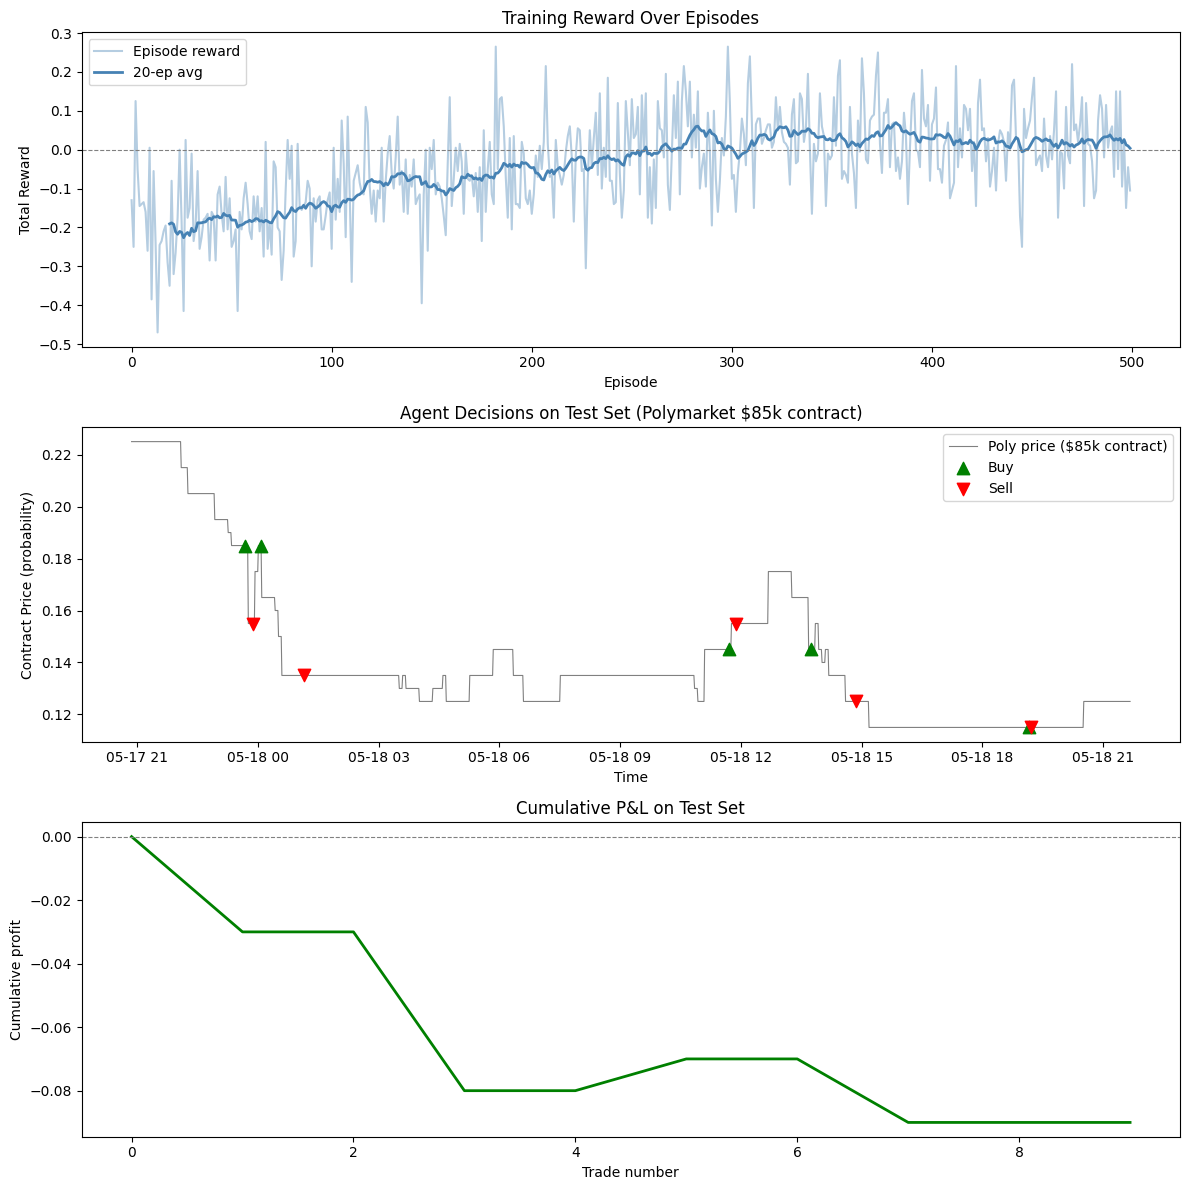

Plot saved as dqn_results.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# ── Plot 1: Training reward curve ─────────────────────────────────────────
axes[0].plot(episode_rewards, alpha=0.4, color="steelblue", label="Episode reward")
# rolling average
window = 20
rolling = pd.Series(episode_rewards).rolling(window).mean()
axes[0].plot(rolling, color="steelblue", linewidth=2, label=f"{window}-ep avg")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("Training Reward Over Episodes")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].legend()

# ── Plot 2: Polymarket price on test set with buy/sell markers ────────────
axes[1].plot(test.index, test["poly_price"], color="gray",
             linewidth=0.8, label="Poly price ($85k contract)")

if len(test_trades) > 0:
    buys  = test_trades[test_trades["action"] == "buy"]
    sells = test_trades[test_trades["action"] == "sell"]
    if len(buys) > 0:
        axes[1].scatter(buys["time"], buys["poly_price"],
                       marker="^", color="green", s=80, zorder=5, label="Buy")
    if len(sells) > 0:
        axes[1].scatter(sells["time"], sells["poly_price"],
                       marker="v", color="red", s=80, zorder=5, label="Sell")

axes[1].set_title("Agent Decisions on Test Set (Polymarket $85k contract)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Contract Price (probability)")
axes[1].legend()

# ── Plot 3: Cumulative P&L on test set ────────────────────────────────────
if "pnl" in test_trades.columns:
    cumulative_pnl = test_trades["pnl"].fillna(0).cumsum()
    axes[2].plot(cumulative_pnl.values, color="green", linewidth=2)
    axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[2].set_title("Cumulative P&L on Test Set")
    axes[2].set_xlabel("Trade number")
    axes[2].set_ylabel("Cumulative profit")
else:
    axes[2].text(0.5, 0.5, "No completed trades in test set",
                ha="center", va="center", transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig("dqn_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as dqn_results.png")